<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Classical%20cryptography%20techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

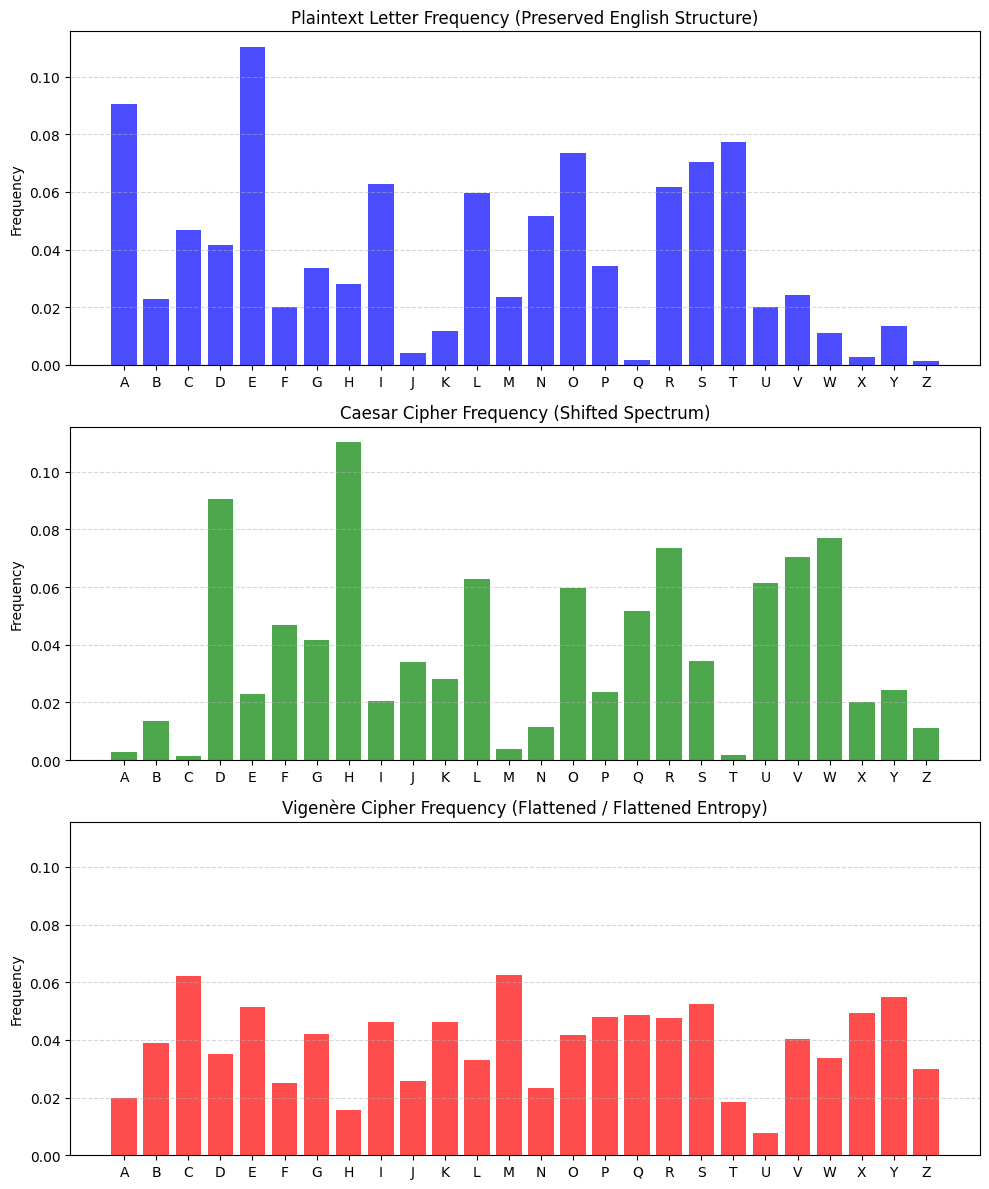

In [3]:
import urllib.request
import collections
import matplotlib.pyplot as plt
import numpy as np

# Download a classic text dataset (Shakespeare's Hamlet)
url = "https://gutenberg.org"
text = urllib.request.urlopen(url).read().decode('utf-8')

# Clean and filter text (subset for performance)
plaintext = "".join([c.upper() for c in text if c.isalpha()][:5000])

# 1. Caesar Cipher Implementation
def caesar_encrypt(text, shift):
    result = ""
    for char in text:
        result += chr((ord(char) - 65 + shift) % 26 + 65)
    return result

# 2. Vigenere Cipher Implementation
def vigenere_encrypt(text, key):
    result = ""
    key_length = len(key)
    for i, char in enumerate(text):
        shift = ord(key[i % key_length]) - 65
        result += chr((ord(char) - 65 + shift) % 26 + 65)
    return result

caesar_text = caesar_encrypt(plaintext, shift=3)
vigenere_text = vigenere_encrypt(plaintext, key="KEY")
# Function to calculate letter frequencies
def get_frequencies(t):
    counts = collections.Counter(t)
    total = len(t)
    return {char: counts.get(char, 0) / total for char in [chr(i) for i in range(65, 91)]}

p_freq = get_frequencies(plaintext)
c_freq = get_frequencies(caesar_text)
v_freq = get_frequencies(vigenere_text)

# Plotting insights
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharey=True)
chars = list(p_freq.keys())

axes[0].bar(chars, p_freq.values(), color='b', alpha=0.7)
axes[0].set_title("Plaintext Letter Frequency (Preserved English Structure)")

axes[1].bar(chars, c_freq.values(), color='g', alpha=0.7)
axes[1].set_title("Caesar Cipher Frequency (Shifted Spectrum)")

axes[2].bar(chars, v_freq.values(), color='r', alpha=0.7)
axes[2].set_title("Vigenère Cipher Frequency (Flattened / Flattened Entropy)")

for ax in axes:
    ax.set_ylabel("Frequency")
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
